# Objetivo 2

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

In [2]:
LGB_PARAMS = dict(
    objective="binary",
    metric="auc",
    boosting_type="gbdt",

    learning_rate=0.03,
    num_leaves=63,
    max_depth=8,

    min_child_samples=30,

    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,

    reg_alpha=0.1,
    reg_lambda=0.1,

    n_estimators=500,

    verbose=-1,
    random_state=42,
    n_jobs=-1,
)

In [3]:
bolivia_train = pd.read_csv('../data/bolivia_train_cleaned.csv')
brasil_train = pd.read_csv('../data/brasil_train_cleaned.csv')
guate_train = pd.read_csv('../data/guatemala_train_cleaned.csv')
bolivia_test = pd.read_csv('../data/bolivia_test_cleaned.csv')
brasil_test = pd.read_csv('../data/brasil_test_cleaned.csv')
guate_test = pd.read_csv('../data/guatemala_test_cleaned.csv')

In [4]:
dfs = [bolivia_train, bolivia_test, brasil_train, brasil_test]
def print_desbalance(df):
    print(df['is_fraud'].value_counts())

for df in dfs:
    print_desbalance(df)

is_fraud
0    79645
1     4191
Name: count, dtype: int64
is_fraud
0    15439
1      728
Name: count, dtype: int64
is_fraud
0    81262
1     2680
Name: count, dtype: int64
is_fraud
0    15533
1      525
Name: count, dtype: int64


In [5]:
"""
Federated Fraud Detection - LightGBM con 3 Metodologías
=========================================================
Bolivia + Brasil → predicción sobre Guatemala (30% = 3 tercios × 10%)

Metodologías:
  Tercio 1 → Modelo 1: FedAvg simulado (promediar pesos de modelos por banco)
  Tercio 2 → Modelo 2: Federated con domain-agnostic features + SMOTE
  Tercio 3 → Modelo 3: Stacking federado (meta-modelo sobre predicciones de ambos bancos)

Desbalance: ~19:1 → se manejan con scale_pos_weight / SMOTE / threshold tuning
"""

bolivia_fe = pd.concat([bolivia_train, bolivia_test], ignore_index=True)
brasil_fe  = pd.concat([brasil_train,  brasil_test],  ignore_index=True)
guate_fe   = pd.concat([guate_train,   guate_test],   ignore_index=True)

print(f"Bolivia total: {len(bolivia_fe):,}  fraudes: {bolivia_fe['is_fraud'].sum():,}")
print(f"Brasil  total: {len(brasil_fe):,}  fraudes: {brasil_fe['is_fraud'].sum():,}")
print(f"Guatemala total (inferencia): {len(guate_fe):,}")

EXCLUDE_COLS = {'is_fraud'}
 
def get_feature_cols(df, exclude=EXCLUDE_COLS):
    return [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]
 
COMMON_FEATURES = sorted(
    set(get_feature_cols(bolivia_fe)) &
    set(get_feature_cols(brasil_fe)) &
    set(get_feature_cols(guate_fe)))


n_guate = len(guate_fe)
t1 = n_guate // 3

guate_t1 = guate_fe.iloc[:t1].copy()            





Bolivia total: 100,003  fraudes: 4,919
Brasil  total: 100,000  fraudes: 3,205
Guatemala total (inferencia): 100,000


In [6]:
def get_spw(y):
    neg = (y == 0).sum()
    pos = (y == 1).sum()
    return neg / pos

In [7]:
X_bra_inicial = brasil_fe[COMMON_FEATURES].fillna(0)
y_bra_inicial = brasil_fe["is_fraud"]


X_bol_inicial = bolivia_fe[COMMON_FEATURES].fillna(0)
y_bol_inicial = bolivia_fe["is_fraud"]

In [8]:
combined = pd.concat(
    [bolivia_fe, brasil_fe],
    ignore_index=True
)

In [9]:
X_global_inicial = combined[COMMON_FEATURES].fillna(0)
y_global_inicial = combined["is_fraud"]

In [10]:
X_bol, X_bol_val, y_bol, y_bol_val = train_test_split(
    X_bol_inicial,
    y_bol_inicial,
    test_size=0.20,
    stratify=y_bol_inicial,
    random_state=42
)

In [11]:
X_bra, X_bra_val, y_bra, y_bra_val = train_test_split(
    X_bra_inicial,
    y_bra_inicial,
    test_size=0.20,
    stratify=y_bra_inicial,
    random_state=42
)

In [12]:
X_global, X_global_val, y_global, y_global_val = train_test_split(
    X_global_inicial,
    y_global_inicial,
    test_size=0.20,
    stratify=y_global_inicial,
    random_state=42
)

In [13]:
spw_bol = get_spw(bolivia_fe.is_fraud)
spw_bra = get_spw(brasil_fe.is_fraud)

combined_tmp = pd.concat(
    [bolivia_fe, brasil_fe]
)

spw_global = get_spw(
    combined_tmp.is_fraud
)

print(spw_bol)
print(spw_bra)
print(spw_global)

19.329945110794878
30.201248049921997
23.61878385032004


In [14]:
LGB_PARAMS = dict(
    objective="binary",
    metric="auc",
    boosting_type="gbdt",

    learning_rate=0.03,
    num_leaves=63,
    max_depth=8,

    min_child_samples=30,

    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,

    reg_alpha=0.1,
    reg_lambda=0.1,

    n_estimators=500,

    verbose=-1,
    random_state=42,
    n_jobs=-1,
)

In [15]:

model_bol = lgb.LGBMClassifier(
    objective='binary',
    scale_pos_weight=spw_bol,

    n_estimators=500,
    learning_rate=0.03,

    num_leaves=63,
    max_depth=8,

    random_state=42,
    n_jobs=-1
)

model_bol.fit(X_bol, y_bol)

[LightGBM] [Info] Number of positive: 3935, number of negative: 76067
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024490 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1081
[LightGBM] [Info] Number of data points in the train set: 80002, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.049186 -> initscore=-2.961704
[LightGBM] [Info] Start training from score -2.961704
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,8
,learning_rate,0.03
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [16]:

m_bra = lgb.LGBMClassifier(
    **LGB_PARAMS,
    scale_pos_weight=spw_bra
)

m_bra.fit(X_bra, y_bra)

,boosting_type,'gbdt'
,num_leaves,63
,max_depth,8
,learning_rate,0.03
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,30


In [17]:
X_g1 = guate_t1[COMMON_FEATURES].fillna(0)

prob_bol = model_bol.predict_proba(X_g1)[:,1]
prob_bra = m_bra.predict_proba(X_g1)[:,1]

In [18]:
w_bol = len(bolivia_fe) / (len(bolivia_fe)+len(brasil_fe))
w_bra = len(brasil_fe) / (len(bolivia_fe)+len(brasil_fe))

In [19]:
prob_fedavg = (
    w_bol * prob_bol
    + w_bra * prob_bra
)

In [20]:
fedavg_results = pd.DataFrame({
    "prob_fraud": prob_fedavg,
    "is_fraud": prob_fedavg >= 0.50
})

fedavg_results.to_excel(
    "fedavg_tercio1.xlsx",
    index=False
)

In [21]:
# Validación federada
X_fed_val = pd.concat(
    [X_bol_val, X_bra_val],
    ignore_index=True
)

y_fed_val = pd.concat(
    [y_bol_val, y_bra_val],
    ignore_index=True
)

In [22]:
# Predicción Bolivia sobre validación federada
prob_bol_val = model_bol.predict_proba(
    X_fed_val
)[:, 1]

# Predicción Brasil sobre validación federada
prob_bra_val = m_bra.predict_proba(
    X_fed_val
)[:, 1]

# Ensemble federado
prob_fedavg_val = (
    w_bol * prob_bol_val +
    w_bra * prob_bra_val
)

pred_fedavg_val = (
    prob_fedavg_val >= 0.50
).astype(int)

In [23]:

print("========== FEDAVG ==========")

print(
    "ROC-AUC:",
    roc_auc_score(
        y_fed_val,
        prob_fedavg_val
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_fed_val,
        prob_fedavg_val
    )
)

print(
    "Recall:",
    recall_score(
        y_fed_val,
        pred_fedavg_val
    )
)

print(
    "Precision:",
    precision_score(
        y_fed_val,
        pred_fedavg_val
    )
)

print(
    "F1:",
    f1_score(
        y_fed_val,
        pred_fedavg_val
    )
)

========== FEDAVG ==========
ROC-AUC: 0.8733976844502173
PR-AUC: 0.6835904242962094
Recall: 0.7163076923076923
Precision: 0.4529182879377432
F1: 0.5549463647199047


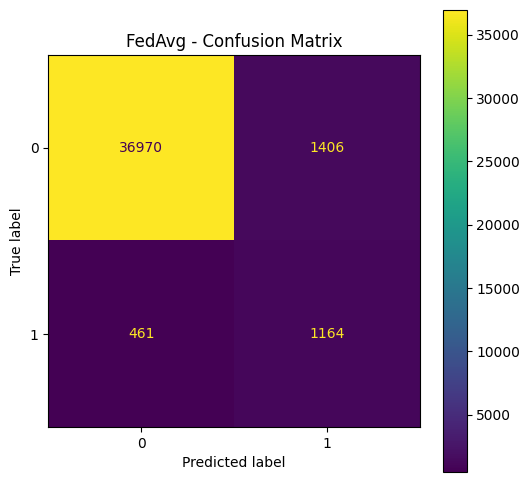

In [24]:
cm = confusion_matrix(
    y_fed_val,
    pred_fedavg_val
)

fig, ax = plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(ax=ax)

plt.title("FedAvg - Confusion Matrix")

plt.show()

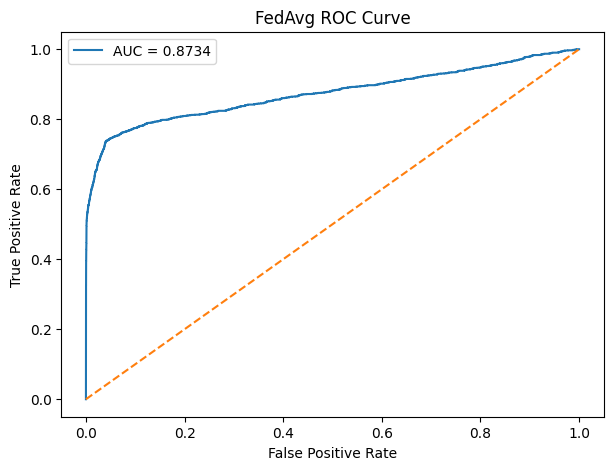

In [25]:
fpr, tpr, _ = roc_curve(
    y_fed_val,
    prob_fedavg_val
)

auc = roc_auc_score(
    y_fed_val,
    prob_fedavg_val
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("FedAvg ROC Curve")

plt.legend()

plt.show()

## Modelo 2

In [26]:
m_global = lgb.LGBMClassifier(
    **LGB_PARAMS,
    scale_pos_weight=spw_global
)

m_global.fit(
    X_global,
    y_global
)

,boosting_type,'gbdt'
,num_leaves,63
,max_depth,8
,learning_rate,0.03
,n_estimators,500
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,30


In [27]:
X_g2 = guate_t1[COMMON_FEATURES].fillna(0)

prob_global = m_global.predict_proba(X_g2)[:,1]

In [28]:
global_results = pd.DataFrame({
    "prob_fraud": prob_global,
    "is_fraud": prob_global >= 0.50
})

global_results.to_excel(
    "global_pooling_tercio2.xlsx",
    index=False
)

In [29]:
prob_global_val = m_global.predict_proba(
    X_global_val
)[:,1]

pred_global_val = (
    prob_global_val >= 0.50
).astype(int)

In [30]:


print("========== GLOBAL POOLING ==========")

print(
    f"ROC-AUC   : {roc_auc_score(y_global_val, prob_global_val):.4f}"
)

print(
    f"PR-AUC    : {average_precision_score(y_global_val, prob_global_val):.4f}"
)

print(
    f"Recall    : {recall_score(y_global_val, pred_global_val):.4f}"
)

print(
    f"Precision : {precision_score(y_global_val, pred_global_val):.4f}"
)

print(
    f"F1        : {f1_score(y_global_val, pred_global_val):.4f}"
)

========== GLOBAL POOLING ==========
ROC-AUC   : 0.8825
PR-AUC    : 0.7718
Recall    : 0.7483
Precision : 0.6882
F1        : 0.7170


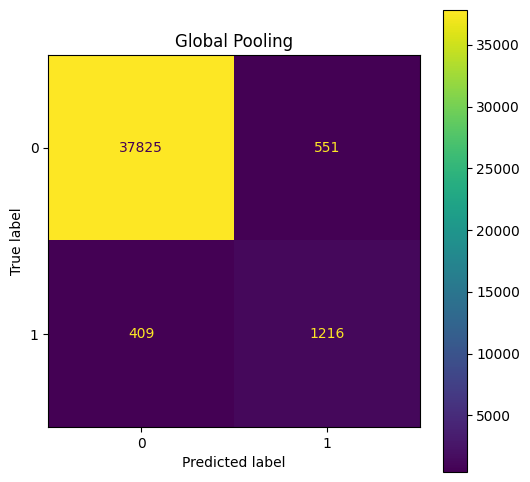

In [31]:
cm = confusion_matrix(
    y_global_val,
    pred_global_val
)

fig, ax = plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(ax=ax)

plt.title("Global Pooling")
plt.show()

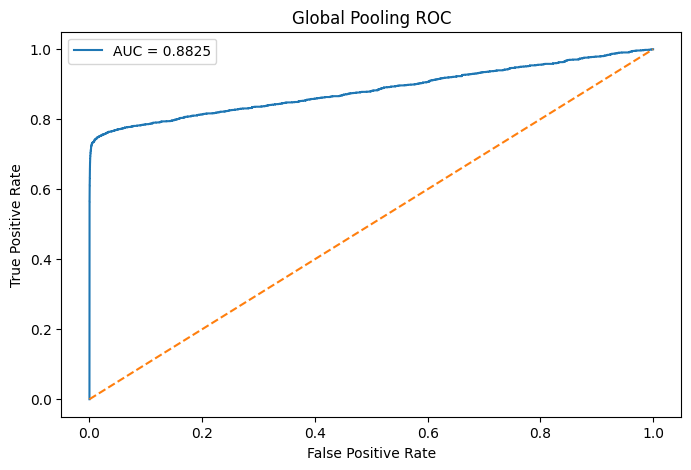

In [32]:

fpr, tpr, _ = roc_curve(
    y_global_val,
    prob_global_val
)

auc = roc_auc_score(
    y_global_val,
    prob_global_val
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Global Pooling ROC")

plt.legend()

plt.show()

## Modelo 3

In [33]:
model_robust = lgb.LGBMClassifier(
    objective='binary',

    scale_pos_weight=spw_global,

    n_estimators=700,

    learning_rate=0.02,

    num_leaves=31,
    max_depth=6,

    min_child_samples=100,

    reg_alpha=1.0,
    reg_lambda=1.0,

    feature_fraction=0.7,
    bagging_fraction=0.7,
    bagging_freq=5,

    random_state=42,
    n_jobs=-1
)

In [34]:
model_robust.fit(
    X_global,
    y_global
)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.02
,n_estimators,700
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,100


In [35]:
X_g3 = guate_t1[COMMON_FEATURES].fillna(0)

prob_robust = model_robust.predict_proba(
    X_g3
)[:,1]

In [36]:
pd.DataFrame({
    "prob_fraud": prob_robust,
    "is_fraud": prob_robust >= 0.50
}).to_excel(
    "regularized_pooling_tercio3.xlsx",
    index=False
)

In [37]:
prob_global_val_m3 = model_robust.predict_proba(
    X_global_val
)[:,1]

pred_global_val_m3 = (
    prob_global_val_m3 >= 0.50
).astype(int)

In [38]:


print("========== GLOBAL POOLING ROBUSTO ==========")

print(
    f"ROC-AUC   : {roc_auc_score(y_global_val, prob_global_val_m3):.4f}"
)

print(
    f"PR-AUC    : {average_precision_score(y_global_val, prob_global_val_m3):.4f}"
)

print(
    f"Recall    : {recall_score(y_global_val, pred_global_val_m3):.4f}"
)

print(
    f"Precision : {precision_score(y_global_val, pred_global_val_m3):.4f}"
)

print(
    f"F1        : {f1_score(y_global_val, pred_global_val_m3):.4f}"
)

========== GLOBAL POOLING ROBUSTO ==========
ROC-AUC   : 0.8866
PR-AUC    : 0.7729
Recall    : 0.7532
Precision : 0.6108
F1        : 0.6746


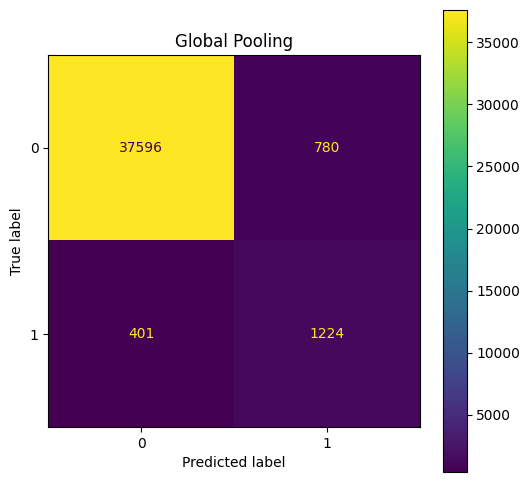

In [39]:
cm = confusion_matrix(
    y_global_val,
    pred_global_val_m3
)

fig, ax = plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(ax=ax)

plt.title("Global Pooling")
plt.show()

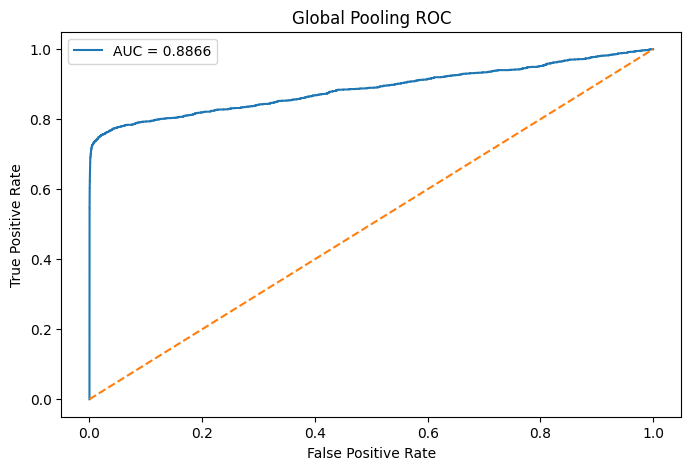

In [40]:


fpr, tpr, _ = roc_curve(
    y_global_val,
    prob_global_val_m3
)

auc = roc_auc_score(
    y_global_val,
    prob_global_val_m3
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Global Pooling ROC")

plt.legend()

plt.show()